In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
image_paths = [
    "landscape.jpg",
    "potrait.jpeg",
    "building.jpg"
]

images = []

for path in image_paths:
    img = cv2.imread(path)

    if img is None:
        print(f"Failed to load: {path}")
    else:

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        images.append((path, img))
        print(f"Successfully loaded: {path}")

print(f"\nTotal images loaded: {len(images)}")

Successfully loaded: landscape.jpg
Successfully loaded: potrait.jpeg
Successfully loaded: building.jpg

Total images loaded: 3


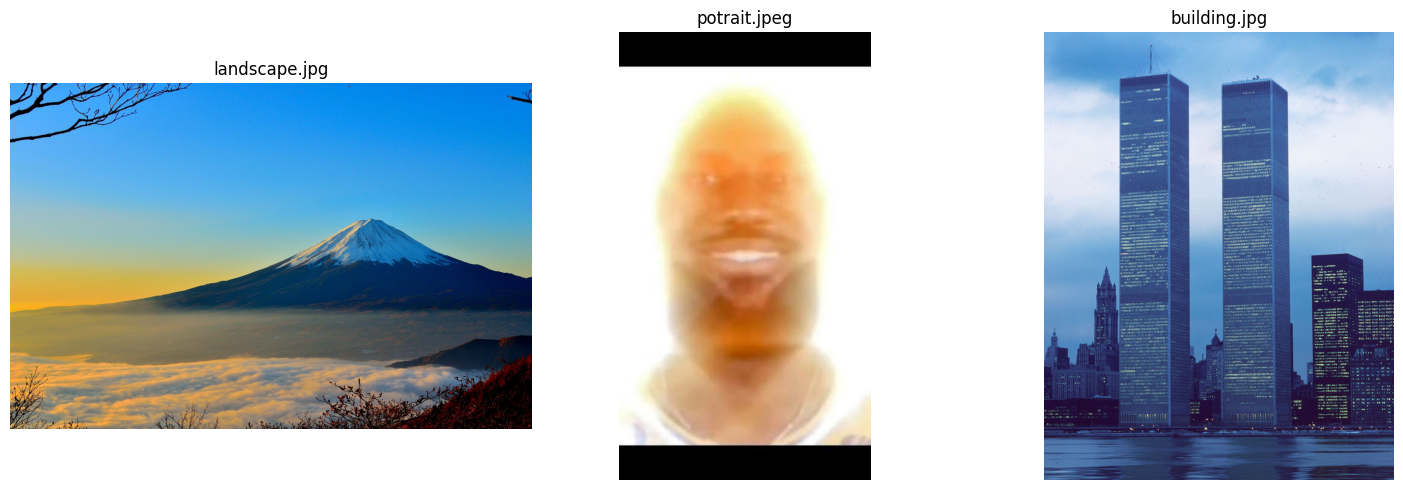

In [7]:


plt.figure(figsize=(15, 5))

for i, (name, img) in enumerate(images):
    plt.subplot(1, len(images), i + 1)
    plt.imshow(img)
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
def max_downsampling(img, new_size):
    height, width = img.shape[:2]
    new_width, new_height = new_size

    result = np.zeros(
        (new_height, new_width, 3),
        dtype=np.uint8
    )

    scale_x = width / new_width
    scale_y = height / new_height

    for y in range(new_height):
        for x in range(new_width):

            x_start = int(x * scale_x)
            x_end = int((x + 1) * scale_x)

            y_start = int(y * scale_y)
            y_end = int((y + 1) * scale_y)

            region = img[
                y_start:y_end,
                x_start:x_end
            ]

            result[y, x] = np.max(
                region,
                axis=(0, 1)
            )

    return result

In [9]:
if not images:
    print("Error: No images were loaded. Please ensure image files are in the correct directory and loaded successfully in the previous cells.")
else:
    name, original = images[0]

    max_result = max_downsampling(
        original,
        (128, 128)
    )

    print("Original size:", original.shape)
    print("Downsampled size:", max_result.shape)

Original size: (848, 1280, 3)
Downsampled size: (128, 128, 3)


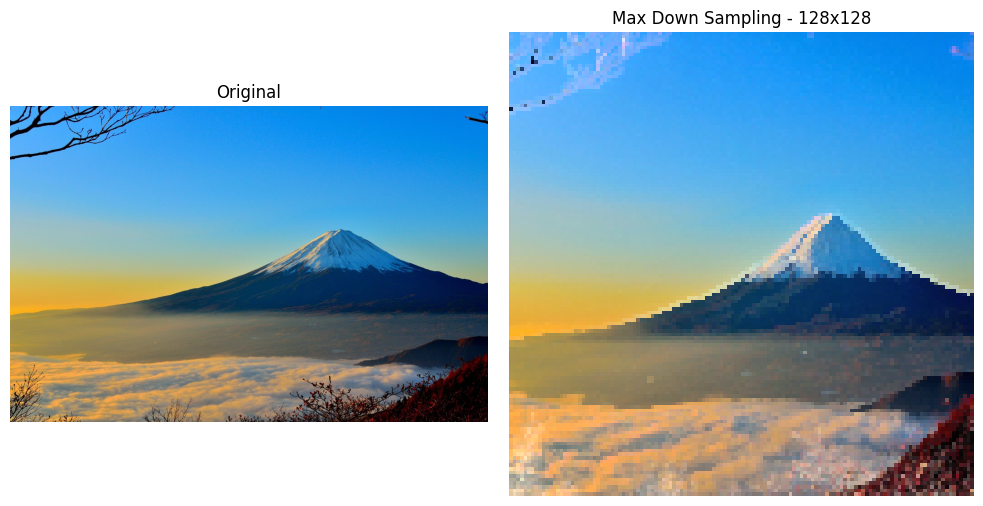

In [10]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(max_result)
plt.title("Max Down Sampling - 128x128")
plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
def average_downsampling(img, new_size):
    height, width = img.shape[:2]
    new_width, new_height = new_size

    result = np.zeros(
        (new_height, new_width, 3),
        dtype=np.uint8
    )

    scale_x = width / new_width
    scale_y = height / new_height

    for y in range(new_height):
        for x in range(new_width):

            x_start = int(x * scale_x)
            x_end = int((x + 1) * scale_x)

            y_start = int(y * scale_y)
            y_end = int((y + 1) * scale_y)

            region = img[
                y_start:y_end,
                x_start:x_end
            ]

            result[y, x] = np.mean(
                region,
                axis=(0, 1)
            )

    return result

In [12]:
average_result = average_downsampling(
    original,
    (128, 128)
)

In [ ]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(average_result)
plt.title("Average Down Sampling - 128x128")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def median_downsampling(img, new_size):
    height, width = img.shape[:2]
    new_width, new_height = new_size

    result = np.zeros(
        (new_height, new_width, 3),
        dtype=np.uint8
    )

    scale_x = width / new_width
    scale_y = height / new_height

    for y in range(new_height):
        for x in range(new_width):

            x_start = int(x * scale_x)
            x_end = int((x + 1) * scale_x)

            y_start = int(y * scale_y)
            y_end = int((y + 1) * scale_y)

            region = img[
                y_start:y_end,
                x_start:x_end
            ]

            result[y, x] = np.median(
                region,
                axis=(0, 1)
            )

    return result

In [ ]:
median_result = median_downsampling(
    original,
    (128, 128)
)

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(max_result)
plt.title("Max")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(average_result)
plt.title("Average")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(median_result)
plt.title("Median")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:

target_size = (128, 128)


downsampled_results = {}


for name, img in images:
    max_result = max_downsampling(img, target_size)
    average_result = average_downsampling(img, target_size)
    median_result = median_downsampling(img, target_size)

    downsampled_results[name] = {
        "Max": max_result,
        "Average": average_result,
        "Median": median_result
    }

print("Down sampling completed for all images!")

In [ ]:
for name, img in images:

    plt.figure(figsize=(16, 4))


    plt.subplot(1, 4, 1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")


    plt.subplot(1, 4, 2)
    plt.imshow(downsampled_results[name]["Max"])
    plt.title("Max")
    plt.axis("off")


    plt.subplot(1, 4, 3)
    plt.imshow(downsampled_results[name]["Average"])
    plt.title("Average")
    plt.axis("off")


    plt.subplot(1, 4, 4)
    plt.imshow(downsampled_results[name]["Median"])
    plt.title("Median")
    plt.axis("off")

    plt.suptitle(f"Down Sampling Comparison - {name}")
    plt.tight_layout()
    plt.show()

In [ ]:
def upsampling_nearest(img, new_size):
    return cv2.resize(
        img,
        new_size,
        interpolation=cv2.INTER_NEAREST
    )

In [ ]:
def upsampling_bilinear(img, new_size):
    return cv2.resize(
        img,
        new_size,
        interpolation=cv2.INTER_LINEAR
    )

In [ ]:
def upsampling_bicubic(img, new_size):
    return cv2.resize(
        img,
        new_size,
        interpolation=cv2.INTER_CUBIC
    )

In [ ]:
upsampled_results = {}

for name, img in images:


    height, width = img.shape[:2]
    original_size = (width, height)

    upsampled_results[name] = {}


    for down_method, small_img in downsampled_results[name].items():

        nearest = upsampling_nearest(
            small_img,
            original_size
        )

        bilinear = upsampling_bilinear(
            small_img,
            original_size
        )

        bicubic = upsampling_bicubic(
            small_img,
            original_size
        )

        upsampled_results[name][down_method] = {
            "Nearest Neighbor": nearest,
            "Bilinear": bilinear,
            "Bicubic": bicubic
        }

print("Up sampling completed for all images!")

Up sampling completed for all images!


In [ ]:
for name, img in images:

    plt.figure(figsize=(16, 4))

    plt.subplot(1, 5, 1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 5, 2)
    plt.imshow(downsampled_results[name]["Average"])
    plt.title("Average\n128x128")
    plt.axis("off")

    plt.subplot(1, 5, 3)
    plt.imshow(
        upsampled_results[name]["Average"]["Nearest Neighbor"]
    )
    plt.title("Nearest Neighbor")
    plt.axis("off")

    plt.subplot(1, 5, 4)
    plt.imshow(
        upsampled_results[name]["Average"]["Bilinear"]
    )
    plt.title("Bilinear")
    plt.axis("off")

    plt.subplot(1, 5, 5)
    plt.imshow(
        upsampled_results[name]["Average"]["Bicubic"]
    )
    plt.title("Bicubic")
    plt.axis("off")

    plt.suptitle(f"Up Sampling Comparison - {name}")
    plt.tight_layout()
    plt.show()

In [ ]:
for name, img in images:

    for down_method in ["Max", "Average", "Median"]:

        plt.figure(figsize=(16, 4))


        plt.subplot(1, 5, 1)
        plt.imshow(img)
        plt.title("Original")
        plt.axis("off")


        plt.subplot(1, 5, 2)
        plt.imshow(downsampled_results[name][down_method])
        plt.title(f"{down_method}\n128x128")
        plt.axis("off")


        plt.subplot(1, 5, 3)
        plt.imshow(
            upsampled_results[name][down_method]["Nearest Neighbor"]
        )
        plt.title("Nearest Neighbor")
        plt.axis("off")


        plt.subplot(1, 5, 4)
        plt.imshow(
            upsampled_results[name][down_method]["Bilinear"]
        )
        plt.title("Bilinear")
        plt.axis("off")


        plt.subplot(1, 5, 5)
        plt.imshow(
            upsampled_results[name][down_method]["Bicubic"]
        )
        plt.title("Bicubic")
        plt.axis("off")

        plt.suptitle(
            f"{name} - {down_method} Down Sampling + Up Sampling"
        )

        plt.tight_layout()
        plt.show()

In [ ]:
for name, img in images:

    height, width = img.shape[:2]

    print(f"{name}")
    print(f"Original: {width} x {height}")
    print(f"Down-sampled: 128 x 128")
    print()

# Analysis

## 1. Down Sampling

Down sampling reduces the size of an image by representing a group of pixels with just one pixel. In this experiment the original images were resized to 128 × 128 pixels using three methods: Max, Average and Median down-sampling.

Max down-sampling takes the pixel value from each region. This means that bright spots or areas with intensity become more visible in the final image. It helps keep intensity values but it can also make some parts look brighter than they were in the original image.

Average sampling computes the average value of all pixels within a region. The result is an image because the pixel values are averaged out. However this smoothing can cause details and sharp edges to lose their clarity when the resolution drops.

Median down-sampling picks the value from the group of pixels in each region. Unlike averaging it is not easily influenced by high or very low values. This makes it better at preserving structures and reducing the effect of outliers, such as noise or small bright specks.

All three methods reduce the number of pixels significantly which leads to a loss of information. The differences between them become much clearer in images with textures strong edges or large variations in brightness.

## 2. Up Sampling

After sampling the images were scaled back up to their original size using three interpolation methods: Nearest Neighbor, Bilinear and Bicubic.

Nearest Neighbor interpolation assigns each pixel the value of the closest pixel from the smaller image. This method is fast and easy to use. It often results in a blocky or pixelated appearance—especially when the image is enlarged a lot.

Bilinear interpolation uses the values of surrounding pixels to calculate pixel values. It creates transitions than Nearest Neighbor.. This smoothing can cause some fine lines and edges to appear softer or less defined.

Bicubic interpolation considers a larger set of neighboring pixels to compute each pixel value. Because of this it generally produces a natural and smooth result. It does a job of keeping visual quality compared to simpler methods like Nearest Neighbor.

## 3. Effect of Combining Down Sampling and Up Sampling

The experiment shows that once data is lost during sampling it cannot be fully restored through up-sampling. Even though the final image returns to its size some level of detail is permanently gone.

The sampling method determines what kind of information survives in the smaller image. The sampling method affects how well that smaller image can be rebuilt.

Among the sampling techniques Nearest Neighbor creates the most noticeable pixelation. Bilinear and Bicubic give outputs. These differences stand out in images with sharp edges, complex textures or small features.

## 4. Comparison Between Different Image Characteristics

The three test images have visual traits. The landscape image has colors and natural patterns like trees and water. The portrait image shows features and areas with smooth gradients. The building image has geometric shapes and strong lines.

Because of these differences the impact of sampling varies across the images. Images with edges and fine details show the effects of interpolation more clearly. Smoother images, like portraits seem affected by the process.